In [2]:
import sys
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from kinematics.forward_kinematics import forward_kinematics

np.set_printoptions(precision=6, suppress=True)

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)

Project root: /home/sooyong/robotics_ws/src
Python: /home/sooyong/venvs/perception/bin/python


In [3]:
q = np.zeros(6)

T06, transforms = forward_kinematics(q, return_all=True)

print("T06 =")
print(T06)

T06 =
[[ 1.      0.      0.     -0.8172]
 [ 0.      0.     -1.     -0.2329]
 [ 0.      1.      0.      0.0628]
 [ 0.      0.      0.      1.    ]]


In [4]:
position = T06[:3, 3]
rotation = T06[:3, :3]

print("TCP position [m]:")
print(position)

print("\nRotation matrix:")
print(rotation)

TCP position [m]:
[-0.8172 -0.2329  0.0628]

Rotation matrix:
[[ 1.  0.  0.]
 [ 0.  0. -1.]
 [ 0.  1.  0.]]


In [5]:
orthogonality = rotation.T @ rotation
det_R = np.linalg.det(rotation)

print("R.T @ R =")
print(orthogonality)

print("\ndet(R) =", det_R)

R.T @ R =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

det(R) = 1.0


In [6]:
joint_positions = np.array([
    T[:3, 3] for T in transforms
])

for i, p in enumerate(joint_positions):
    print(f"Frame {i}: {p}")

Frame 0: [0. 0. 0.]
Frame 1: [0.     0.     0.1625]
Frame 2: [-0.425   0.      0.1625]
Frame 3: [-0.8172  0.      0.1625]
Frame 4: [-0.8172 -0.1333  0.1625]
Frame 5: [-0.8172 -0.1333  0.0628]
Frame 6: [-0.8172 -0.2329  0.0628]


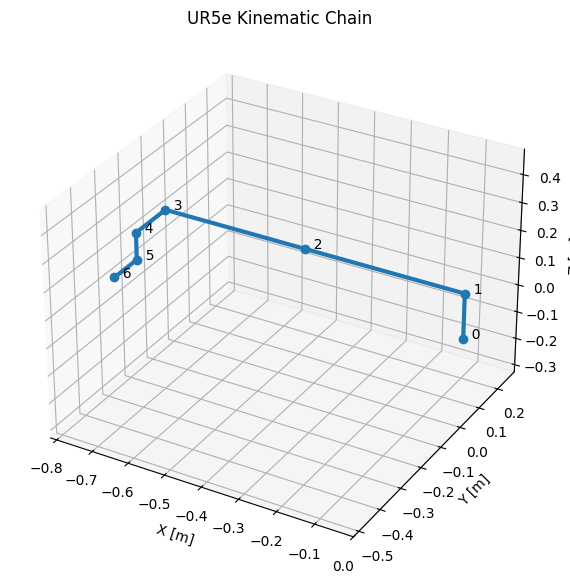

In [9]:
from visualization.robot_plot import plot_robot
plot_robot(transforms);

TCP position:
[-0.4919 -0.1333  0.4879]


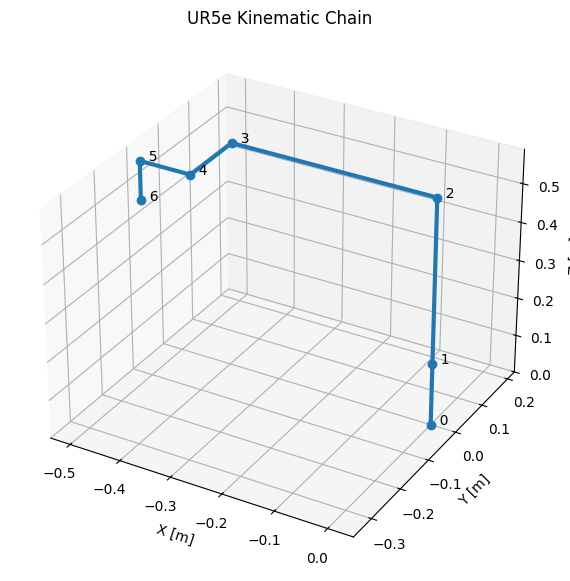

In [10]:
q_test = np.deg2rad([
    0,
    -90,
    90,
    -90,
    -90,
    0
])

T_test, transforms_test = forward_kinematics(
    q_test,
    return_all=True
)

print("TCP position:")
print(T_test[:3, 3])

plot_robot(transforms_test);

In [11]:
test_angle = np.deg2rad(30)

joint_tests = {}

for j in range(6):
    q_test = np.zeros(6)
    q_test[j] = test_angle

    T, Ts = forward_kinematics(q_test, return_all=True)

    joint_tests[j + 1] = {
        "q": q_test,
        "T": T,
        "transforms": Ts
    }

    print(f"Joint {j+1} = +30 deg")
    print("TCP position:", T[:3, 3])
    print()

Joint 1 = +30 deg
TCP position: [-0.591266 -0.610297  0.0628  ]

Joint 2 = +30 deg
TCP position: [-0.657866 -0.2329   -0.332443]

Joint 3 = +30 deg
TCP position: [-0.714805 -0.2329   -0.119943]

Joint 4 = +30 deg
TCP position: [-0.76735  -0.2329    0.076157]

Joint 5 = +30 deg
TCP position: [-0.867    -0.219556  0.0628  ]

Joint 6 = +30 deg
TCP position: [-0.8172 -0.2329  0.0628]



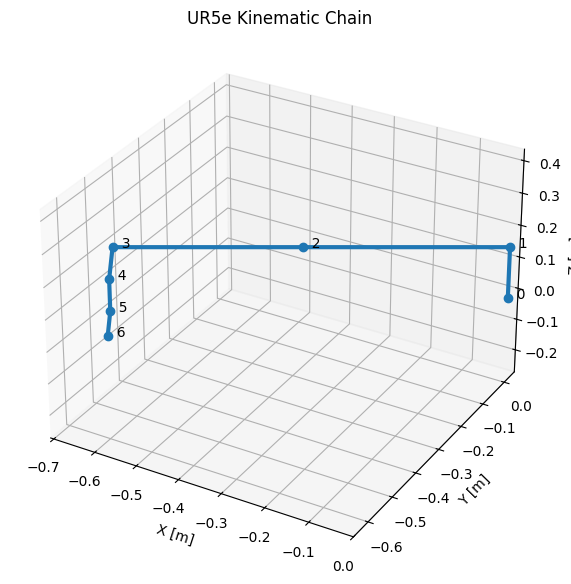

In [12]:
plot_robot(
    joint_tests[1]["transforms"]
);

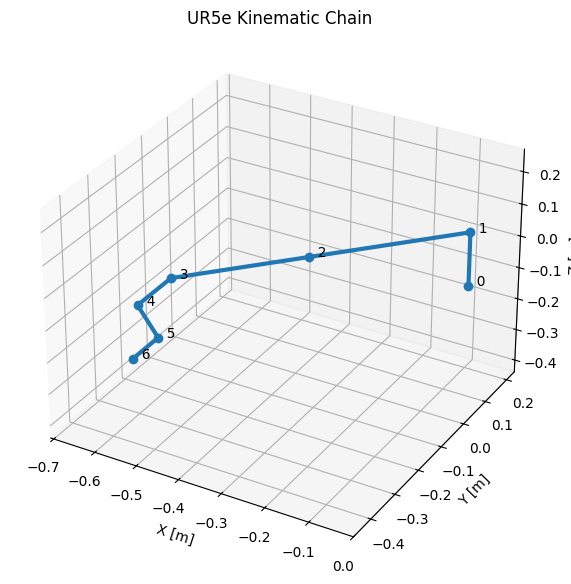

In [13]:
plot_robot(
    joint_tests[2]["transforms"]
);

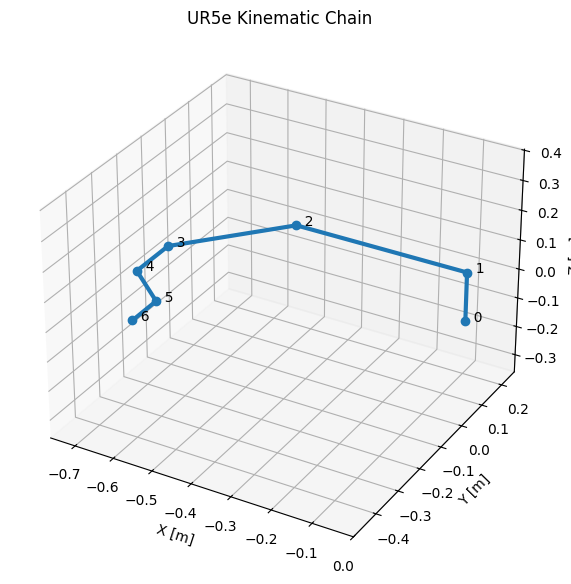

In [14]:
plot_robot(
    joint_tests[3]["transforms"]
);

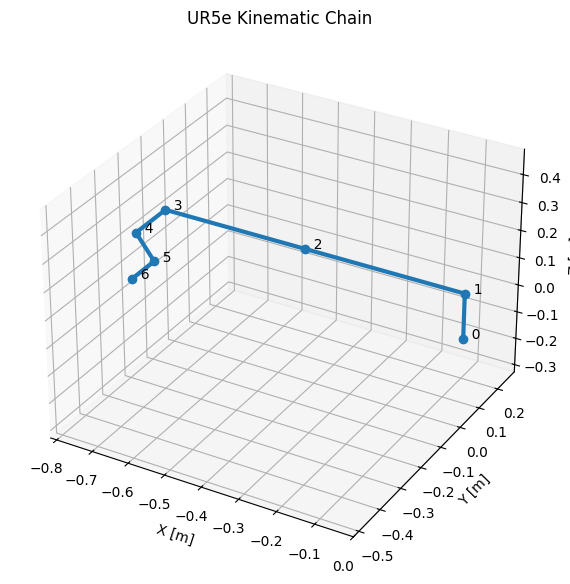

In [15]:
plot_robot(
    joint_tests[4]["transforms"]
);

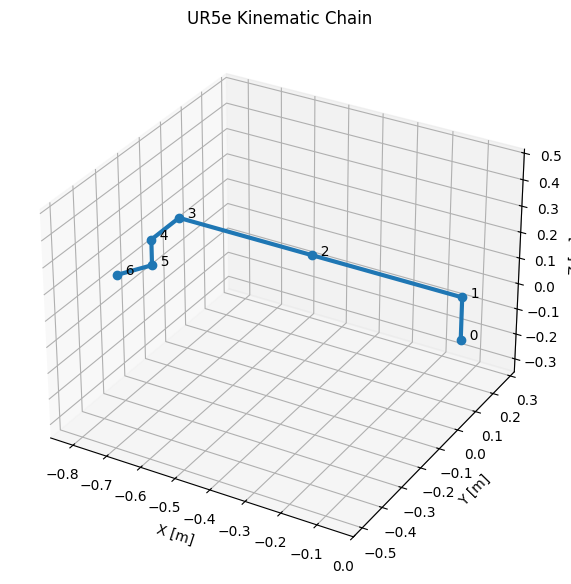

In [16]:
plot_robot(
    joint_tests[5]["transforms"]
);

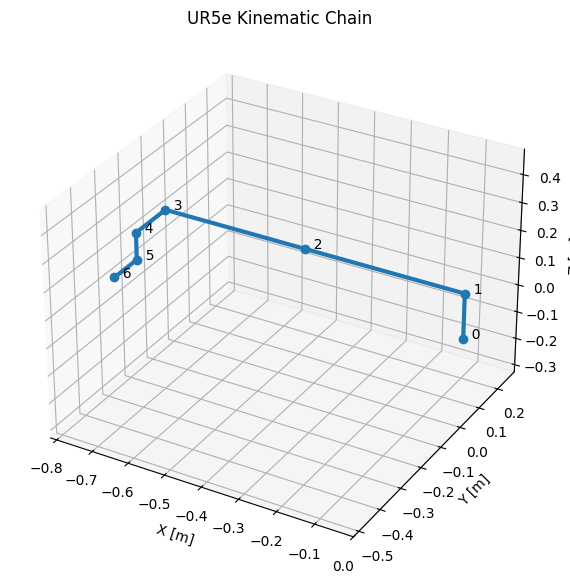

In [17]:
plot_robot(
    joint_tests[6]["transforms"]
);

In [18]:
dq = 1e-6

q0 = np.zeros(6)

T0, Ts0 = forward_kinematics(
    q0,
    return_all=True
)

# Joint 2에 아주 작은 perturbation
q_perturbed = q0.copy()
q_perturbed[1] += dq

T_perturbed = forward_kinematics(q_perturbed)

# Numerical derivative
p0 = T0[:3, 3]
p_perturbed = T_perturbed[:3, 3]

dp_numeric = (p_perturbed - p0) / dq


# Analytical derivative
z1 = Ts0[1][:3, 2]
p_joint1 = Ts0[1][:3, 3]
p_tcp = T0[:3, 3]

dp_analytic = np.cross(
    z1,
    p_tcp - p_joint1
)


print("Numerical derivative:")
print(dp_numeric)

print("\nAnalytical derivative:")
print(dp_analytic)

print("\nDifference:")
print(dp_numeric - dp_analytic)

print("\nError norm:")
print(np.linalg.norm(dp_numeric - dp_analytic))

Numerical derivative:
[ 0.0997  0.     -0.8172]

Analytical derivative:
[ 0.0997 -0.     -0.8172]

Difference:
[0. 0. 0.]

Error norm:
4.11624872005134e-07


In [19]:
dq = 1e-6
q0 = np.zeros(6)

T0, Ts0 = forward_kinematics(
    q0,
    return_all=True
)

p_tcp = T0[:3, 3]

print("Joint | Error norm")
print("-------------------")

for i in range(6):

    # Numerical derivative
    q_perturbed = q0.copy()
    q_perturbed[i] += dq

    T_perturbed = forward_kinematics(q_perturbed)

    dp_numeric = (
        T_perturbed[:3, 3] - p_tcp
    ) / dq

    # Analytical derivative
    z = Ts0[i][:3, 2]
    p_joint = Ts0[i][:3, 3]

    dp_analytic = np.cross(
        z,
        p_tcp - p_joint
    )

    error = np.linalg.norm(
        dp_numeric - dp_analytic
    )

    print(f"  {i+1}   | {error:.3e}")

Joint | Error norm
-------------------
  1   | 4.249e-07
  2   | 4.116e-07
  3   | 2.023e-07
  4   | 4.985e-08
  5   | 4.979e-08
  6   | 6.099e-18


In [20]:
from kinematics.jacobian import geometric_jacobian

In [21]:
q_zero = np.zeros(6)

J_zero = geometric_jacobian(q_zero)

print("Jacobian at q = 0:")
print(J_zero)

Jacobian at q = 0:
[[ 0.2329  0.0997  0.0997  0.0997 -0.0996  0.    ]
 [-0.8172 -0.     -0.      0.      0.      0.    ]
 [ 0.     -0.8172 -0.3922  0.      0.      0.    ]
 [ 0.      0.      0.      0.      0.      0.    ]
 [ 0.     -1.     -1.     -1.     -0.     -1.    ]
 [ 1.      0.      0.      0.     -1.      0.    ]]


In [22]:
dq = 1e-6

q = np.deg2rad([
    10,
    -40,
    60,
    -30,
    45,
    20
])

T = forward_kinematics(q)
p = T[:3, 3]

J = geometric_jacobian(q)

Jv_analytic = J[:3, :]

Jv_numeric = np.zeros((3, 6))

for i in range(6):

    q_perturbed = q.copy()
    q_perturbed[i] += dq

    T_perturbed = forward_kinematics(q_perturbed)

    p_perturbed = T_perturbed[:3, 3]

    Jv_numeric[:, i] = (
        p_perturbed - p
    ) / dq


print("Analytical Jv:")
print(Jv_analytic)

print("\nNumerical Jv:")
print(Jv_numeric)

print("\nDifference:")
print(Jv_numeric - Jv_analytic)

print(
    "\nError norm:",
    np.linalg.norm(
        Jv_numeric - Jv_analytic
    )
)

Analytical Jv:
[[ 0.336215 -0.052282  0.216752  0.08465  -0.080534 -0.      ]
 [-0.733548 -0.009219  0.038219  0.014926  0.057314 -0.      ]
 [ 0.       -0.780787 -0.455218 -0.086671  0.01223  -0.      ]]

Numerical Jv:
[[ 0.336215 -0.052282  0.216752  0.08465  -0.080534  0.      ]
 [-0.733548 -0.009219  0.038219  0.014926  0.057314  0.      ]
 [ 0.       -0.780787 -0.455218 -0.086671  0.01223   0.      ]]

Difference:
[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0. -0.  0.  0. -0.  0.]]

Error norm: 6.2119581030207e-07


In [23]:
def vee(S):
    """
    Convert a 3x3 skew-symmetric matrix
    into a 3D vector.
    """
    return np.array([
        S[2, 1],
        S[0, 2],
        S[1, 0]
    ])

In [24]:
R = T[:3, :3]

Jw_numeric = np.zeros((3, 6))

for i in range(6):

    q_perturbed = q.copy()
    q_perturbed[i] += dq

    T_perturbed = forward_kinematics(
        q_perturbed
    )

    R_perturbed = T_perturbed[:3, :3]

    R_dot = (
        R_perturbed - R
    ) / dq

    omega_skew = R_dot @ R.T

    # Remove finite-difference symmetric error
    omega_skew = 0.5 * (
        omega_skew - omega_skew.T
    )

    Jw_numeric[:, i] = vee(
        omega_skew
    )


Jw_analytic = J[3:, :]

print("Analytical Jw:")
print(Jw_analytic)

print("\nNumerical Jw:")
print(Jw_numeric)

print("\nError norm:")
print(
    np.linalg.norm(
        Jw_numeric - Jw_analytic
    )
)

Analytical Jw:
[[ 0.        0.173648  0.173648  0.173648 -0.17101  -0.562997]
 [ 0.       -0.984808 -0.984808 -0.984808 -0.030154 -0.817287]
 [ 1.        0.        0.        0.       -0.984808  0.122788]]

Numerical Jw:
[[-0.        0.173648  0.173648  0.173648 -0.17101  -0.562997]
 [-0.       -0.984808 -0.984808 -0.984808 -0.030154 -0.817287]
 [ 1.       -0.       -0.       -0.       -0.984808  0.122788]]

Error norm:
1.4381979434589302e-10


In [25]:
singular_values = np.linalg.svd(
    J_zero,
    compute_uv=False
)

print("Singular values:")
print(singular_values)

print(
    "\nRank:",
    np.linalg.matrix_rank(J_zero)
)

Singular values:
[2.105267 1.564865 0.643915 0.531628 0.072326 0.      ]

Rank: 5


In [26]:
q_normal = np.deg2rad([
    10,
    -40,
    60,
    -30,
    45,
    20
])

J_normal = geometric_jacobian(q_normal)

s_normal = np.linalg.svd(
    J_normal,
    compute_uv=False
)

print("Singular values:")
print(s_normal)

print(
    "Rank:",
    np.linalg.matrix_rank(J_normal)
)

print(
    "Condition number:",
    np.linalg.cond(J_normal)
)

Singular values:
[2.030319 1.55996  0.758434 0.467459 0.412385 0.15682 ]
Rank: 6
Condition number: 12.946800864128445


In [27]:
def manipulability(J):
    value = np.linalg.det(J @ J.T)

    # Numerical roundoff protection
    value = max(value, 0.0)

    return np.sqrt(value)


w_zero = manipulability(J_zero)
w_normal = manipulability(J_normal)

print("Zero configuration :", w_zero)
print("Normal configuration:", w_normal)

Zero configuration : 0.0
Normal configuration: 0.07261791122046939


In [28]:
U, S, Vt = np.linalg.svd(J_zero)

lost_direction = U[:, -1]

print("Lost Cartesian direction:")
print(lost_direction)

print("\nLinear component:")
print(lost_direction[:3])

print("\nAngular component:")
print(lost_direction[3:])

Lost Cartesian direction:
[-0. -0.  0. -1. -0.  0.]

Linear component:
[-0. -0.  0.]

Angular component:
[-1. -0.  0.]


In [29]:
q_base = np.deg2rad([
    10,
    -40,
    60,
    -30,
    0,
    20
])

q5_values = np.deg2rad(
    np.linspace(-30, 30, 301)
)

sigma_min = []
condition_numbers = []
manipulabilities = []

for q5 in q5_values:

    q = q_base.copy()
    q[4] = q5

    J = geometric_jacobian(q)

    s = np.linalg.svd(
        J,
        compute_uv=False
    )

    sigma_min.append(s[-1])
    condition_numbers.append(
        np.linalg.cond(J)
    )
    manipulabilities.append(
        manipulability(J)
    )

sigma_min = np.array(sigma_min)
condition_numbers = np.array(condition_numbers)
manipulabilities = np.array(manipulabilities)

q5_deg = np.rad2deg(q5_values)

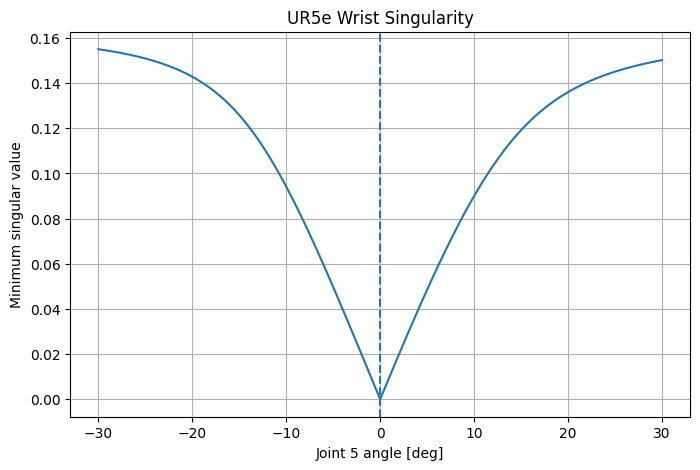

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    q5_deg,
    sigma_min
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Joint 5 angle [deg]")
plt.ylabel("Minimum singular value")
plt.title("UR5e Wrist Singularity")

plt.grid(True)
plt.show()

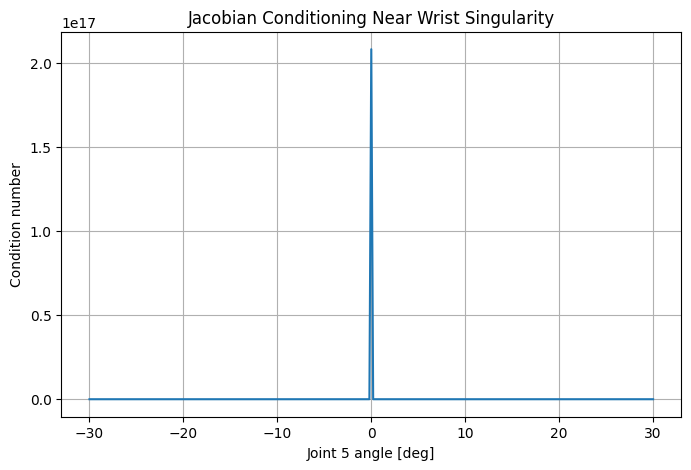

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    q5_deg,
    condition_numbers
)

plt.xlabel("Joint 5 angle [deg]")
plt.ylabel("Condition number")
plt.title("Jacobian Conditioning Near Wrist Singularity")

plt.grid(True)
plt.show()

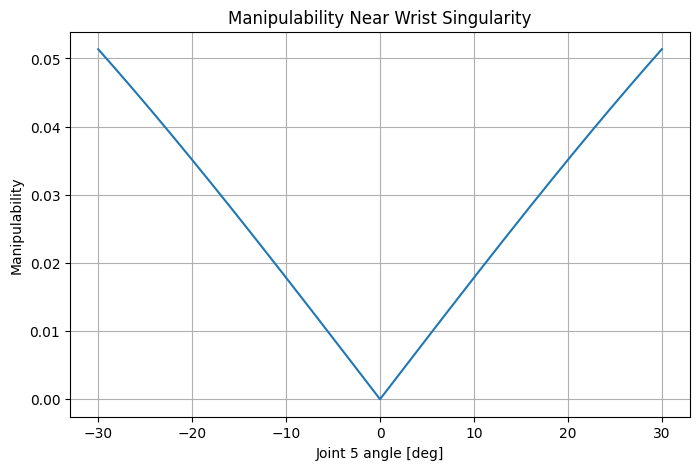

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    q5_deg,
    manipulabilities
)

plt.xlabel("Joint 5 angle [deg]")
plt.ylabel("Manipulability")
plt.title("Manipulability Near Wrist Singularity")

plt.grid(True)
plt.show()

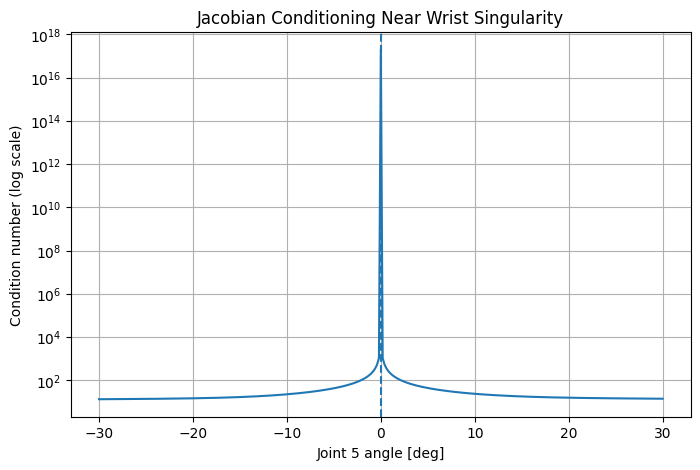

In [33]:
plt.figure(figsize=(8, 5))

plt.semilogy(
    q5_deg,
    condition_numbers
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Joint 5 angle [deg]")
plt.ylabel("Condition number (log scale)")
plt.title("Jacobian Conditioning Near Wrist Singularity")

plt.grid(True, which="both")
plt.show()

In [34]:
xdot_cmd = np.array([
    0.0,
    0.0,
    0.0,
    0.1,
    0.0,
    0.0
])

joint_velocity_norm = []

for q5 in q5_values:

    q = q_base.copy()
    q[4] = q5

    J = geometric_jacobian(q)

    qdot = np.linalg.pinv(J) @ xdot_cmd

    joint_velocity_norm.append(
        np.linalg.norm(qdot)
    )

joint_velocity_norm = np.array(
    joint_velocity_norm
)

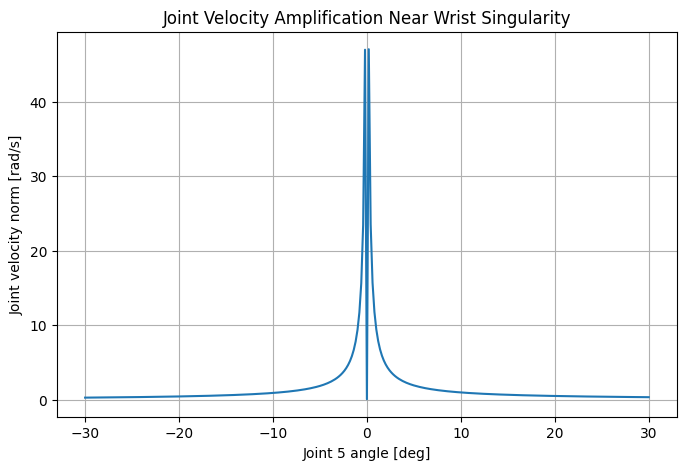

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    q5_deg,
    joint_velocity_norm
)

plt.xlabel("Joint 5 angle [deg]")
plt.ylabel("Joint velocity norm [rad/s]")
plt.title("Joint Velocity Amplification Near Wrist Singularity")

plt.grid(True)
plt.show()

In [36]:
from kinematics.inverse_kinematics import inverse_kinematics

In [37]:
q_true = np.deg2rad([
    20,
    -50,
    70,
    -40,
    60,
    30
])

T_target = forward_kinematics(q_true)

print("Target position:")
print(T_target[:3, 3])

Target position:
[-0.648616 -0.430928  0.289743]


In [38]:
q_initial = np.deg2rad([
    0,
    -30,
    30,
    0,
    30,
    0
])

q_solution, converged, history = inverse_kinematics(
    T_target,
    q_initial
)

print("Converged:", converged)

print("\nTrue q [deg]:")
print(np.rad2deg(q_true))

print("\nIK solution [deg]:")
print(np.rad2deg(q_solution))

print("\nIterations:")
print(len(history))

print("\nFinal error:")
print(history[-1])

Converged: True

True q [deg]:
[ 20. -50.  70. -40.  60.  30.]

IK solution [deg]:
[ 19.99996  -50.000038  70.000074 -40.000028  59.99993   29.999983]

Iterations:
20

Final error:
8.938938140707976e-07


In [39]:
T_solution = forward_kinematics(q_solution)

position_error = np.linalg.norm(
    T_solution[:3, 3]
    - T_target[:3, 3]
)

rotation_difference = (
    T_solution[:3, :3]
    @ T_target[:3, :3].T
)

orientation_error = np.arccos(
    np.clip(
        (np.trace(rotation_difference) - 1) / 2,
        -1.0,
        1.0
    )
)

print(
    "Position error [m]:",
    position_error
)

print(
    "Orientation error [rad]:",
    orientation_error
)

Position error [m]: 4.896376459431516e-07
Orientation error [rad]: 7.480323551900044e-07


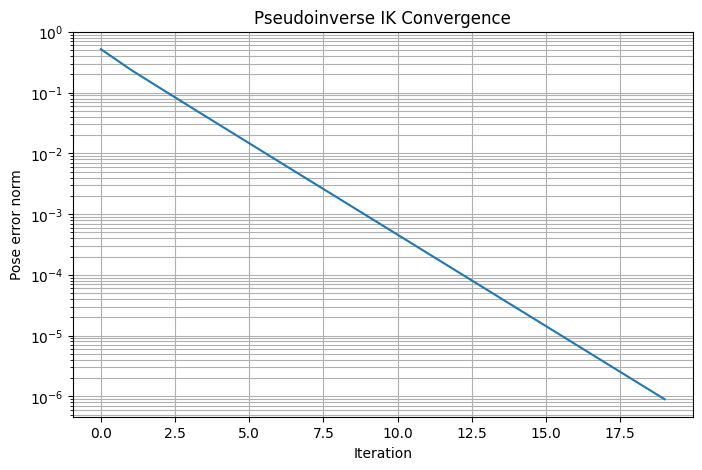

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.semilogy(history)

plt.xlabel("Iteration")
plt.ylabel("Pose error norm")
plt.title("Pseudoinverse IK Convergence")

plt.grid(True, which="both")
plt.show()

In [41]:
initial_guesses = [
    np.deg2rad([0, -30, 30, 0, 30, 0]),
    np.deg2rad([90, -60, 60, -90, 60, 0]),
    np.deg2rad([-90, -60, 60, 90, -60, 0])
]

solutions = []

for q0 in initial_guesses:

    q_sol, conv, hist = inverse_kinematics(
        T_target,
        q0
    )

    solutions.append(q_sol)

    print("Converged:", conv)
    print(
        "Solution [deg]:",
        np.round(
            np.rad2deg(q_sol),
            2
        )
    )
    print(
        "Iterations:",
        len(hist)
    )
    print()

Converged: True
Solution [deg]: [ 20. -50.  70. -40.  60.  30.]
Iterations: 20

Converged: True
Solution [deg]: [ 20. -50.  70. -40.  60.  30.]
Iterations: 24

Converged: True
Solution [deg]: [-5537.68 -3390.83  2099.39 -4271.12 -3141.17 -2677.55]
Iterations: 34



In [42]:
def wrap_to_pi(q):
    return (q + np.pi) % (2 * np.pi) - np.pi


for i, q_sol in enumerate(solutions):

    q_wrapped = wrap_to_pi(q_sol)

    print(
        f"Solution {i+1} [deg]:",
        np.round(np.rad2deg(q_wrapped), 2)
    )

Solution 1 [deg]: [ 20. -50.  70. -40.  60.  30.]
Solution 2 [deg]: [ 20. -50.  70. -40.  60.  30.]
Solution 3 [deg]: [-137.68 -150.83  -60.61   48.88   98.83 -157.55]


In [43]:
for i, q_sol in enumerate(solutions):

    q_wrapped = wrap_to_pi(q_sol)

    T_check = forward_kinematics(q_wrapped)

    position_error = np.linalg.norm(
        T_check[:3, 3] - T_target[:3, 3]
    )

    R_error = (
        T_check[:3, :3]
        @ T_target[:3, :3].T
    )

    orientation_error = np.arccos(
        np.clip(
            (np.trace(R_error) - 1) / 2,
            -1.0,
            1.0
        )
    )

    print(f"Solution {i+1}")
    print("Position error [m]:", position_error)
    print("Orientation error [rad]:", orientation_error)
    print()

Solution 1
Position error [m]: 4.8963764596937e-07
Orientation error [rad]: 7.480323551900044e-07

Solution 2
Position error [m]: 2.440179009738277e-07
Orientation error [rad]: 4.97796925559349e-07

Solution 3
Position error [m]: 3.3506742206793634e-07
Orientation error [rad]: 8.958064535373235e-07



In [46]:
from importlib import reload
import kinematics.inverse_kinematics as ik

reload(ik)

<module 'kinematics.inverse_kinematics' from '/home/sooyong/robotics_ws/src/ur5e_control_analysis/kinematics/inverse_kinematics.py'>

In [47]:
q0_hard = initial_guesses[2]

q_dls, conv_dls, hist_dls, step_hist_dls = (
    ik.inverse_kinematics_dls(
        T_target,
        q0_hard
    )
)

print("Converged:", conv_dls)
print("Iterations:", len(hist_dls))

print(
    "Solution [deg]:",
    np.round(
        np.rad2deg(wrap_to_pi(q_dls)),
        2
    )
)

print("Final error:", hist_dls[-1])

print(
    "Maximum joint update [deg]:",
    np.rad2deg(max(step_hist_dls))
)

Converged: True
Iterations: 41
Solution [deg]: [  20.    -28.73   59.43  129.3   -60.   -150.  ]
Final error: 7.404752061601283e-07
Maximum joint update [deg]: 11.459155902616466


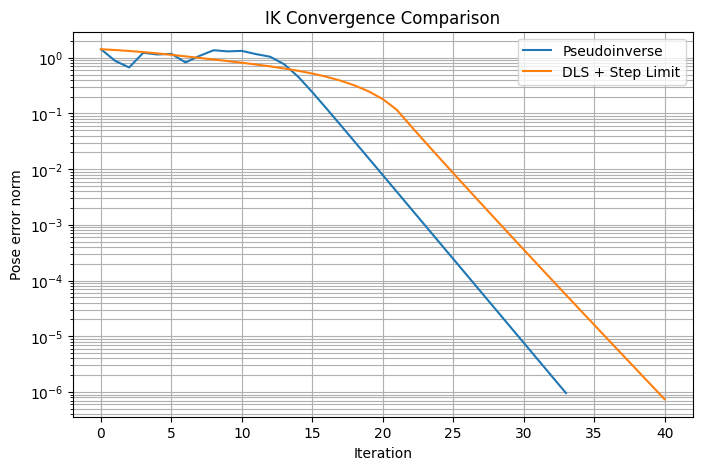

In [48]:
q_pinv, conv_pinv, hist_pinv = inverse_kinematics(
    T_target,
    q0_hard
)

plt.figure(figsize=(8, 5))

plt.semilogy(
    hist_pinv,
    label="Pseudoinverse"
)

plt.semilogy(
    hist_dls,
    label="DLS + Step Limit"
)

plt.xlabel("Iteration")
plt.ylabel("Pose error norm")
plt.title("IK Convergence Comparison")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [49]:
q = q0_hard.copy()

pinv_step_history = []
pinv_error_history = []

for _ in range(500):

    T_current = forward_kinematics(q)

    error = ik.pose_error(
        T_current,
        T_target
    )

    error_norm = np.linalg.norm(error)
    pinv_error_history.append(error_norm)

    if error_norm < 1e-6:
        break

    J = geometric_jacobian(q)

    dq = 0.5 * np.linalg.pinv(J) @ error

    pinv_step_history.append(
        np.linalg.norm(dq)
    )

    q += dq

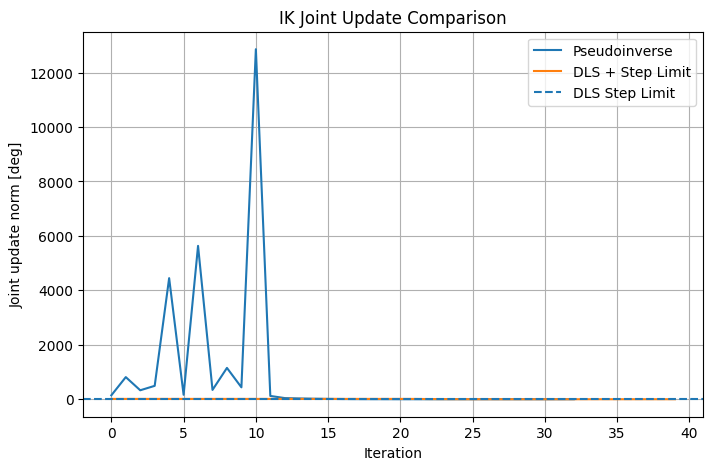

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.rad2deg(pinv_step_history),
    label="Pseudoinverse"
)

plt.plot(
    np.rad2deg(step_hist_dls),
    label="DLS + Step Limit"
)

plt.axhline(
    np.rad2deg(0.2),
    linestyle="--",
    label="DLS Step Limit"
)

plt.xlabel("Iteration")
plt.ylabel("Joint update norm [deg]")
plt.title("IK Joint Update Comparison")

plt.legend()
plt.grid(True)
plt.show()

In [53]:
from models.ur5e_parameters import (
    LINK_MASSES,
    COM_POSITIONS,
    INERTIA_TENSORS
)

print("Moving-link masses [kg]:")
print(LINK_MASSES)

print("\nTotal moving-link mass [kg]:")
print(np.sum(LINK_MASSES))

print("\nCOM positions:")
print(COM_POSITIONS)

print("\nInertia tensor shapes:")
print(INERTIA_TENSORS.shape)

ImportError: cannot import name 'LINK_MASSES' from 'models.ur5e_parameters' (/home/sooyong/robotics_ws/src/ur5e_control_analysis/models/ur5e_parameters.py)

In [54]:
import importlib
import models.ur5e_parameters as params

params = importlib.reload(params)

print("Loaded from:")
print(params.__file__)

print("\nAvailable dynamic parameters:")
print("LINK_MASSES:", hasattr(params, "LINK_MASSES"))
print("COM_POSITIONS:", hasattr(params, "COM_POSITIONS"))
print("INERTIA_TENSORS:", hasattr(params, "INERTIA_TENSORS"))

Loaded from:
/home/sooyong/robotics_ws/src/ur5e_control_analysis/models/ur5e_parameters.py

Available dynamic parameters:
LINK_MASSES: True
COM_POSITIONS: True
INERTIA_TENSORS: True


In [55]:
print("Moving-link masses [kg]:")
print(params.LINK_MASSES)

print("\nTotal moving-link mass [kg]:")
print(np.sum(params.LINK_MASSES))

print("\nCOM positions:")
print(params.COM_POSITIONS)

print("\nInertia tensor shape:")
print(params.INERTIA_TENSORS.shape)

Moving-link masses [kg]:
[3.761 8.058 2.846 1.37  1.3   0.365]

Total moving-link mass [kg]:
17.7

COM positions:
[[ 0.       -0.00193  -0.02561 ]
 [-0.2125    0.        0.11336 ]
 [-0.2422    0.        0.0265  ]
 [ 0.       -0.01634  -0.0018  ]
 [ 0.        0.01634  -0.0018  ]
 [ 0.        0.       -0.001159]]

Inertia tensor shape:
(6, 3, 3)


In [56]:
for i, I in enumerate(params.INERTIA_TENSORS):

    symmetric = np.allclose(I, I.T)
    eigenvalues = np.linalg.eigvalsh(I)

    print(f"Link {i+1}")
    print("  symmetric:", symmetric)
    print("  eigenvalues:", eigenvalues)
    print("  positive definite:", np.all(eigenvalues > 0))
    print()

Link 1
  symmetric: True
  eigenvalues: [0.006025 0.007    0.007031]
  positive definite: True

Link 2
  symmetric: True
  eigenvalues: [0.015059 0.332472 0.333881]
  positive definite: True

Link 3
  symmetric: True
  eigenvalues: [0.003971 0.07851  0.078793]
  positive definite: True

Link 4
  symmetric: True
  eigenvalues: [0.001199 0.001424 0.001655]
  positive definite: True

Link 5
  symmetric: True
  eigenvalues: [0.000958 0.001286 0.001356]
  positive definite: True

Link 6
  symmetric: True
  eigenvalues: [0.000187 0.000189 0.000258]
  positive definite: True



In [57]:
import importlib
import dynamics.rigid_body_dynamics as rbd

importlib.reload(rbd)

q_zero = np.zeros(6)

com_zero = rbd.link_com_positions(q_zero)

for i, p in enumerate(com_zero):
    print(
        f"Link {i+1} CoM [m]:",
        np.round(p, 6)
    )

Link 1 CoM [m]: [0.      0.02561 0.16057]
Link 2 CoM [m]: [-0.6375  -0.11336  0.1625 ]
Link 3 CoM [m]: [-1.0594 -0.0265  0.1625]
Link 4 CoM [m]: [-0.8172  -0.11696  0.1643 ]
Link 5 CoM [m]: [-0.8172  -0.1315   0.07914]
Link 6 CoM [m]: [-0.8172   -0.231741  0.0628  ]


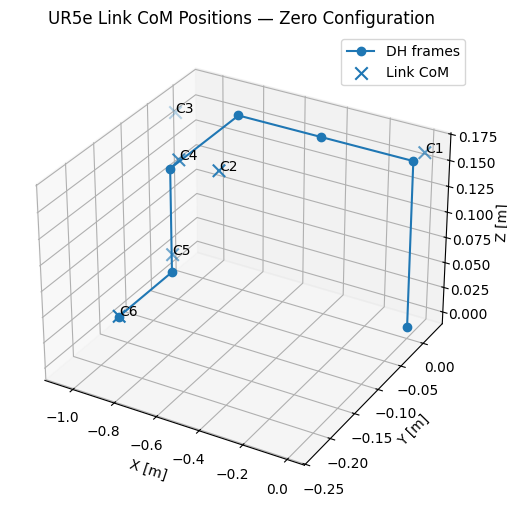

In [58]:
T06, transforms = forward_kinematics(
    q_zero,
    return_all=True
)

frame_positions = np.array([
    T[:3, 3]
    for T in transforms
])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    frame_positions[:, 0],
    frame_positions[:, 1],
    frame_positions[:, 2],
    "o-",
    label="DH frames"
)

ax.scatter(
    com_zero[:, 0],
    com_zero[:, 1],
    com_zero[:, 2],
    marker="x",
    s=80,
    label="Link CoM"
)

for i, p in enumerate(com_zero):
    ax.text(
        p[0],
        p[1],
        p[2],
        f"C{i+1}"
    )

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.set_title("UR5e Link CoM Positions — Zero Configuration")
ax.legend()

plt.show()

In [59]:
import importlib
import dynamics.rigid_body_dynamics as rbd

importlib.reload(rbd)

q_zero = np.zeros(6)

com_zero = rbd.link_com_positions(q_zero)

for i, p in enumerate(com_zero):
    print(
        f"Link {i+1} CoM [m]:",
        np.round(p, 6)
    )

Link 1 CoM [m]: [ 0.      -0.00193  0.13689]
Link 2 CoM [m]: [-0.2125  -0.11336  0.1625 ]
Link 3 CoM [m]: [-0.6672 -0.0265  0.1625]
Link 4 CoM [m]: [-0.8172  -0.1315   0.14616]
Link 5 CoM [m]: [-0.8172  -0.14964  0.0646 ]
Link 6 CoM [m]: [-0.8172   -0.231741  0.0628  ]


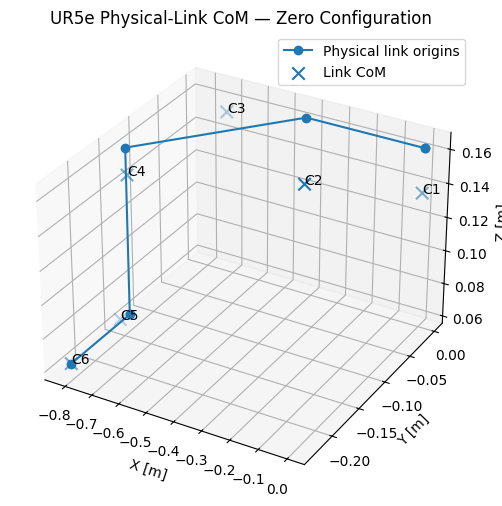

In [60]:
link_T = rbd.physical_link_transforms(q_zero)

link_origins = np.array([
    T[:3, 3]
    for T in link_T
])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    link_origins[:, 0],
    link_origins[:, 1],
    link_origins[:, 2],
    "o-",
    label="Physical link origins"
)

ax.scatter(
    com_zero[:, 0],
    com_zero[:, 1],
    com_zero[:, 2],
    marker="x",
    s=80,
    label="Link CoM"
)

for i, p in enumerate(com_zero):
    ax.text(
        p[0],
        p[1],
        p[2],
        f"C{i+1}"
    )

ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.set_zlabel("Z [m]")
ax.set_title(
    "UR5e Physical-Link CoM — Zero Configuration"
)

ax.legend()
plt.show()

In [61]:
import importlib
import numpy as np
import dynamics.rigid_body_dynamics as rbd

importlib.reload(rbd)

T_links = rbd.physical_link_transforms(np.zeros(6))

for i, T in enumerate(T_links, start=1):
    print(
        f"Link {i}:",
        np.round(T[:3, 3], 7)
    )

Link 1: [0.     0.     0.1625]
Link 2: [0.     0.     0.1625]
Link 3: [ 0.425  -0.      0.1625]
Link 4: [0.8172 0.1333 0.1625]
Link 5: [0.8172 0.1333 0.0628]
Link 6: [0.8172 0.2329 0.0628]


In [62]:
import numpy as np
import dynamics.rigid_body_dynamics as rbd

T_links = rbd.physical_link_transforms(np.zeros(6))

for i, T in enumerate(T_links, start=1):
    print(f"\nLink {i}")
    print(np.round(T[:3, :3], 7))


Link 1
[[-1. -0.  0.]
 [ 0. -1.  0.]
 [ 0.  0.  1.]]

Link 2
[[-1. -0.  0.]
 [ 0. -0.  1.]
 [ 0.  1.  0.]]

Link 3
[[-1. -0.  0.]
 [ 0. -0.  1.]
 [ 0.  1.  0.]]

Link 4
[[-1. -0.  0.]
 [ 0. -0.  1.]
 [ 0.  1.  0.]]

Link 5
[[-1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -1.]]

Link 6
[[-1. -0.  0.]
 [ 0. -0.  1.]
 [ 0.  1.  0.]]


In [63]:
import importlib
import numpy as np
import dynamics.rigid_body_dynamics as rbd

importlib.reload(rbd)

q = np.zeros(6)

M = rbd.mass_matrix(q)

np.set_printoptions(
    precision=6,
    suppress=True
)

print("M(q=0):")
print(M)

print("\nShape:")
print(M.shape)

print("\nSymmetry error:")
print(np.linalg.norm(M - M.T))

eigvals = np.linalg.eigvalsh(M)

print("\nEigenvalues:")
print(eigvals)

print("\nPositive definite:")
print(np.all(eigvals > 0.0))

M(q=0):
[[ 4.257329  0.030564  0.030566  0.030573 -0.012661 -0.000001]
 [ 0.030564  4.087813  1.530374  0.019252 -0.005711  0.000258]
 [ 0.030566  1.530374  0.731532  0.019252 -0.005711  0.000258]
 [ 0.030573  0.019252  0.019252  0.019252 -0.005711  0.000258]
 [-0.012661 -0.005711 -0.005711 -0.005711  0.005039  0.000001]
 [-0.000001  0.000258  0.000258  0.000258  0.000001  0.000258]]

Shape:
(6, 6)

Symmetry error:
0.0

Eigenvalues:
[0.000252 0.003028 0.019787 0.139513 4.253963 4.68468 ]

Positive definite:
True


In [64]:
q_test = np.deg2rad([
    10.0,
    -40.0,
    60.0,
    -30.0,
    45.0,
    20.0
])

M_test = rbd.mass_matrix(q_test)

print("M(q_test):")
print(M_test)

print("\nSymmetry error:")
print(np.linalg.norm(M_test - M_test.T))

eigvals_test = np.linalg.eigvalsh(M_test)

print("\nEigenvalues:")
print(eigvals_test)

print("\nPositive definite:")
print(np.all(eigvals_test > 0.0))

print("\nCondition number:")
print(np.linalg.cond(M_test))

M(q_test):
[[ 3.103413 -0.173015  0.093256  0.027184 -0.039033  0.000031]
 [-0.173015  3.342034  1.208672  0.046755 -0.003372  0.000182]
 [ 0.093256  1.208672  0.833906  0.071411 -0.011963  0.000182]
 [ 0.027184  0.046755  0.071411  0.021196 -0.004035  0.000182]
 [-0.039033 -0.003372 -0.011963 -0.004035  0.005039  0.000001]
 [ 0.000031  0.000182  0.000182  0.000182  0.000001  0.000258]]

Symmetry error:
0.0

Eigenvalues:
[0.000255 0.003714 0.013381 0.344965 3.091497 3.852034]

Positive definite:
True

Condition number:
15101.463335151482


In [65]:
import numpy as np

M_python = np.array([
    [ 3.103413, -0.173015,  0.093256,  0.027184, -0.039033,  0.000031],
    [-0.173015,  3.342034,  1.208672,  0.046755, -0.003372,  0.000182],
    [ 0.093256,  1.208672,  0.833906,  0.071411, -0.011963,  0.000182],
    [ 0.027184,  0.046755,  0.071411,  0.021196, -0.004035,  0.000182],
    [-0.039033, -0.003372, -0.011963, -0.004035,  0.005039,  0.000001],
    [ 0.000031,  0.000182,  0.000182,  0.000182,  0.000001,  0.000258]
])

M_isaac = np.array([
    [ 0.190949,  0.577553,  0.190616,  0.022832,  0.001588, -0.000082],
    [ 0.577553,  4.405492,  1.766620,  0.180290,  0.020583, -0.000107],
    [ 0.190616,  1.766620,  0.886346,  0.098301,  0.011131, -0.000107],
    [ 0.022832,  0.180290,  0.098301,  0.022536,  0.002303, -0.000107],
    [ 0.001588,  0.020583,  0.011131,  0.002303,  0.005350,  0.000000],
    [-0.000082, -0.000107, -0.000107, -0.000107,  0.000000,  0.000258]
])

Delta = M_python - M_isaac

relative_error = (
    np.linalg.norm(Delta, ord='fro')
    / np.linalg.norm(M_isaac, ord='fro')
)

print("Delta M:")
print(Delta)

print("\nAbsolute Frobenius error:",
      np.linalg.norm(Delta, ord='fro'))

print("Relative Frobenius error:",
      relative_error)

print("Relative error [%]:",
      100 * relative_error)

Delta M:
[[ 2.912464 -0.750568 -0.09736   0.004352 -0.040621  0.000113]
 [-0.750568 -1.063458 -0.557948 -0.133535 -0.023955  0.000289]
 [-0.09736  -0.557948 -0.05244  -0.02689  -0.023094  0.000289]
 [ 0.004352 -0.133535 -0.02689  -0.00134  -0.006338  0.000289]
 [-0.040621 -0.023955 -0.023094 -0.006338 -0.000311  0.000001]
 [ 0.000113  0.000289  0.000289  0.000289  0.000001  0.      ]]

Absolute Frobenius error: 3.3804080235162446
Relative Frobenius error: 0.6469854973434966
Relative error [%]: 64.69854973434967


In [66]:
import numpy as np
from dynamics.rigid_body_dynamics import joint_origins_axes

q_test = np.deg2rad([10, -40, 60, -30, 45, 20])

origins, axes = joint_origins_axes(q_test)

np.set_printoptions(precision=6, suppress=True)

print("=== Joint origins ===")
for i, p in enumerate(origins):
    print(f"Joint {i+1}: {p}")

print("\n=== Joint axes ===")
for i, z in enumerate(axes):
    print(f"Joint {i+1}: {z}")

=== Joint origins ===
Joint 1: [0.     0.     0.1625]
Joint 2: [0.     0.     0.1625]
Joint 3: [0.320623 0.056534 0.435685]
Joint 4: [0.660424 0.251807 0.301544]
Joint 5: [0.677474 0.254813 0.203359]
Joint 6: [0.733548 0.336215 0.215589]

=== Joint axes ===
Joint 1: [0. 0. 1.]
Joint 2: [-0.173648  0.984808  0.      ]
Joint 3: [-0.173648  0.984808  0.      ]
Joint 4: [-0.173648  0.984808  0.      ]
Joint 5: [ 0.17101   0.030154 -0.984808]
Joint 6: [0.562997 0.817287 0.122788]


In [67]:
import numpy as np
from dynamics.rigid_body_dynamics import physical_link_transforms

q_test = np.deg2rad([10, -40, 60, -30, 45, 20])

T_links = physical_link_transforms(q_test)

names = [
    "shoulder_link",
    "upper_arm_link",
    "forearm_link",
    "wrist_1_link",
    "wrist_2_link",
    "wrist_3_link",
]

print("=== Python link positions ===")

for name, T in zip(names, T_links):
    p = T[:3, 3]
    print(
        f"{name:20s}: "
        f"[{p[0]: .6f}, {p[1]: .6f}, {p[2]: .6f}]"
    )

=== Python link positions ===
shoulder_link       : [ 0.000000,  0.000000,  0.162500]
upper_arm_link      : [ 0.000000,  0.000000,  0.162500]
forearm_link        : [ 0.320623,  0.056534,  0.435685]
wrist_1_link        : [ 0.660424,  0.251807,  0.301544]
wrist_2_link        : [ 0.677474,  0.254813,  0.203359]
wrist_3_link        : [ 0.733548,  0.336215,  0.215589]


In [68]:
import numpy as np
from dynamics.rigid_body_dynamics import physical_link_transforms

q_deg = np.array([10, -40, 60, -30, 45, 20], dtype=float)
q = np.deg2rad(q_deg)

T_links = physical_link_transforms(q)

link_names = [
    "shoulder_link",
    "upper_arm_link",
    "forearm_link",
    "wrist_1_link",
    "wrist_2_link",
    "wrist_3_link",
]

print("=== Python physical-link poses ===")

for name, T in zip(link_names, T_links):
    print(f"\n{name}")
    print("p =", np.round(T[:3, 3], 6))
    print("R =")
    print(np.round(T[:3, :3], 6))

=== Python physical-link poses ===

shoulder_link
p = [0.     0.     0.1625]
R =
[[-0.984808  0.173648  0.      ]
 [-0.173648 -0.984808  0.      ]
 [ 0.        0.        1.      ]]

upper_arm_link
p = [0.     0.     0.1625]
R =
[[-0.754407 -0.633022 -0.173648]
 [-0.133022 -0.111619  0.984808]
 [-0.642788  0.766044  0.      ]]

forearm_link
p = [0.320623 0.056534 0.435685]
R =
[[-0.925417  0.336824 -0.173648]
 [-0.163176  0.059391  0.984808]
 [ 0.34202   0.939693  0.      ]]

wrist_1_link
p = [0.660424 0.251807 0.301544]
R =
[[-0.969846 -0.17101  -0.173648]
 [-0.17101  -0.030154  0.984808]
 [-0.173648  0.984808  0.      ]]

wrist_2_link
p = [0.677474 0.254813 0.203359]
R =
[[-0.808573  0.562997  0.17101 ]
 [ 0.575442  0.817287  0.030154]
 [-0.122788  0.122788 -0.984808]]

wrist_3_link
p = [0.733548 0.336215 0.215589]
R =
[[-0.818299  0.115851  0.562997]
 [ 0.530425 -0.225148  0.817287]
 [ 0.221441  0.967412  0.122788]]


In [69]:
import numpy as np
from dynamics.rigid_body_dynamics import (
    physical_link_transforms,
    joint_origins_axes,
)

q_deg = np.array([10, -40, 60, -30, 45, 20], dtype=float)
q = np.deg2rad(q_deg)

# Joint origins and axes in world frame
origins, axes = joint_origins_axes(q)

# wrist_3_link frame origin
T_links = physical_link_transforms(q)
p_end = T_links[-1][:3, 3]

Jv = np.zeros((3, 6))
Jw = np.zeros((3, 6))

for i in range(6):
    Jv[:, i] = np.cross(axes[i], p_end - origins[i])
    Jw[:, i] = axes[i]

J_python = np.vstack((Jv, Jw))

print("=== Python wrist_3_link Jacobian ===")
print(np.round(J_python, 6))

=== Python wrist_3_link Jacobian ===
[[-0.336215  0.052282 -0.216752 -0.08465   0.080534  0.      ]
 [ 0.733548  0.009219 -0.038219 -0.014926 -0.057314  0.      ]
 [ 0.       -0.780787 -0.455218 -0.086671  0.01223   0.      ]
 [ 0.       -0.173648 -0.173648 -0.173648  0.17101   0.562997]
 [ 0.        0.984808  0.984808  0.984808  0.030154  0.817287]
 [ 1.        0.        0.        0.       -0.984808  0.122788]]


In [70]:
import numpy as np
from dynamics.rigid_body_dynamics import link_com_positions
from models.ur5e_parameters import LINK_MASSES

q_deg = np.array([10, -40, 60, -30, 45, 20], dtype=float)
q = np.deg2rad(q_deg)

gravity = np.array([0.0, 0.0, -9.81])

def potential_energy(q):
    coms = link_com_positions(q)

    U = 0.0
    for m, p in zip(LINK_MASSES, coms):
        U += -m * gravity @ p

    return U

def gravity_vector(q, eps=1e-6):
    gq = np.zeros(6)

    for i in range(6):
        dq = np.zeros(6)
        dq[i] = eps

        U_plus  = potential_energy(q + dq)
        U_minus = potential_energy(q - dq)

        gq[i] = (U_plus - U_minus) / (2.0 * eps)

    return gq

g_python = gravity_vector(q)

print("Potential energy [J]:")
print(potential_energy(q))

print("\nPython gravity vector [Nm]:")
print(np.round(g_python, 6))

Potential energy [J]:
45.794268019388404

Python gravity vector [Nm]:
[  0.       -49.685494 -18.034631  -0.707495   0.068868   0.      ]
